<a href="https://colab.research.google.com/github/Chaejangwoo/2026-1_CV/blob/main/HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 재현성을 위한 난수 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_size, num_classes, activation_fn, init_std=0.1):
        super(FlexibleMLP, self).__init__()

        # 3개의 은닉층을 가지는 MLP 구조 (예: 256 -> 128 -> 64)
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.out = nn.Linear(64, num_classes)

        self.activation = activation_fn

        # 각 층의 출력(Activation)과 기울기(Gradient)를 저장하기 위한 딕셔너리
        self.activations = {}
        self.gradients = {}

        # 가중치 초기화 (정규분포 사용, std 값 조절 가능)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=init_std)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # 2D 이미지가 입력될 경우 1D 텐서로 변환
        x = x.view(x.size(0), -1)

        # --- Layer 1 ---
        x = self.fc1(x)
        x = self.activation(x)
        self.activations['layer1'] = x.detach().cpu().numpy()

        # 역전파 시 Layer 1의 기울기를 추출하여 gradients 딕셔너리에 저장
        if x.requires_grad:
            x.register_hook(lambda grad: self.gradients.update({'layer1': grad.cpu().numpy()}))

        # --- Layer 2 ---
        x = self.fc2(x)
        x = self.activation(x)
        self.activations['layer2'] = x.detach().cpu().numpy()
        if x.requires_grad:
            x.register_hook(lambda grad: self.gradients.update({'layer2': grad.cpu().numpy()}))

        # --- Layer 3 ---
        x = self.fc3(x)
        x = self.activation(x)
        self.activations['layer3'] = x.detach().cpu().numpy()
        if x.requires_grad:
            x.register_hook(lambda grad: self.gradients.update({'layer3': grad.cpu().numpy()}))

        # --- Output Layer ---
        x = self.out(x)
        return x

In [3]:
def train_and_evaluate(model, train_loader, test_loader, loss_fn, optimizer, epochs, scheduler=None, is_mse=False):
    history = {'train_loss': [], 'test_acc': [], 'dead_relu_ratio': [], 'grad_norm_l1': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)

            # MSE Loss 사용 시 Softmax 적용 및 정답 레이블의 One-hot 인코딩 처리
            if is_mse:
                outputs = torch.softmax(outputs, dim=1)
                targets_one_hot = torch.zeros_like(outputs).scatter_(1, targets.unsqueeze(1), 1)
                loss = loss_fn(outputs, targets_one_hot)
            else:
                loss = loss_fn(outputs, targets)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            # Layer 1에서 출력값이 0 이하인 뉴런의 비율(Dead ReLU) 계산
            dead_ratio = (model.activations['layer1'] <= 0).mean()

        if scheduler:
            scheduler.step()

        history['train_loss'].append(running_loss / len(train_loader))
        history['dead_relu_ratio'].append(dead_ratio)

        # Layer 1의 기울기 절대값 평균을 계산하여 Gradient 크기 추적
        if 'layer1' in model.gradients:
            history['grad_norm_l1'].append(np.mean(np.abs(model.gradients['layer1'])))

        # --- 평가(Evaluation) 루프 ---
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for inputs, targets in test_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()

        accuracy = 100 * correct / total
        history['test_acc'].append(accuracy)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {history['train_loss'][-1]:.4f}, Test Acc: {accuracy:.2f}%")

    return history

=== [실험 A] CrossEntropy vs MSE ===


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.5MB/s]



[CrossEntropy 학습]
Epoch [1/20] Loss: 0.4842, Test Acc: 83.65%
Epoch [10/20] Loss: 0.2194, Test Acc: 88.13%
Epoch [20/20] Loss: 0.1427, Test Acc: 88.61%

[MSE 학습]
Epoch [1/20] Loss: 0.0257, Test Acc: 84.52%
Epoch [10/20] Loss: 0.0131, Test Acc: 88.32%
Epoch [20/20] Loss: 0.0099, Test Acc: 88.31%


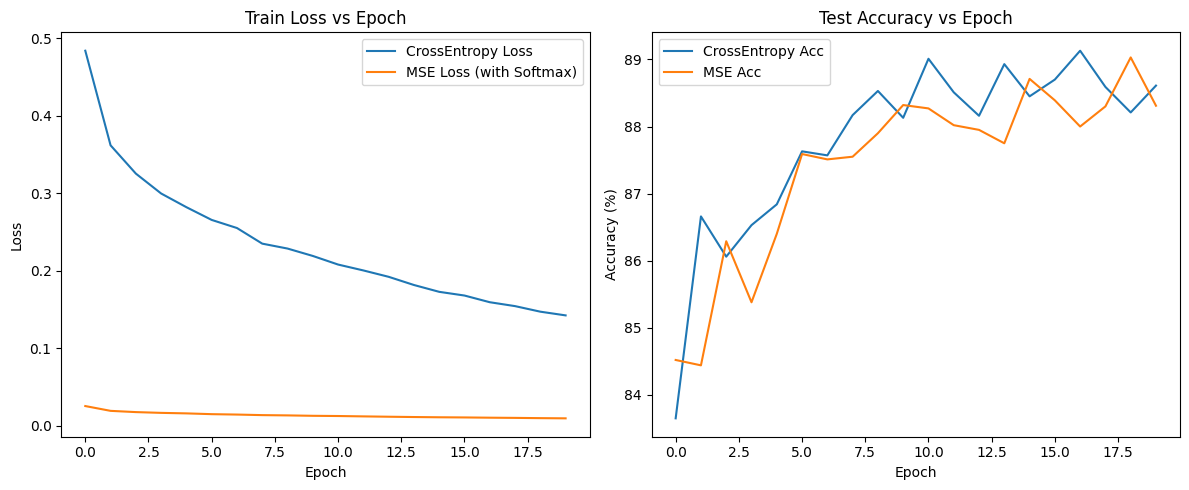

In [4]:
print("=== [실험 A] CrossEntropy vs MSE ===")

# Fashion-MNIST 데이터 로드
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader_fm = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader_fm = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 모델, 손실함수, 옵티마이저 설정
model_ce = FlexibleMLP(input_size=784, num_classes=10, activation_fn=nn.ReLU())
model_mse = FlexibleMLP(input_size=784, num_classes=10, activation_fn=nn.ReLU())

loss_fn_ce = nn.CrossEntropyLoss()
loss_fn_mse = nn.MSELoss()

optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

# 학습 실행
print("\n[CrossEntropy 학습]")
hist_ce = train_and_evaluate(model_ce, train_loader_fm, test_loader_fm, loss_fn_ce, optimizer_ce, epochs=20, is_mse=False)
print("\n[MSE 학습]")
hist_mse = train_and_evaluate(model_mse, train_loader_fm, test_loader_fm, loss_fn_mse, optimizer_mse, epochs=20, is_mse=True)

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_ce['train_loss'], label='CrossEntropy Loss')
plt.plot(hist_mse['train_loss'], label='MSE Loss (with Softmax)')
plt.title('Train Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_ce['test_acc'], label='CrossEntropy Acc')
plt.plot(hist_mse['test_acc'], label='MSE Acc')
plt.title('Test Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()

=== [실험 B] 활성화 함수 비교 ===

[ReLU 학습]
Epoch [1/50] Loss: 0.4101, Test Acc: 89.00%
Epoch [10/50] Loss: 0.0083, Test Acc: 99.50%
Epoch [20/50] Loss: 0.0015, Test Acc: 100.00%
Epoch [30/50] Loss: 0.0000, Test Acc: 100.00%
Epoch [40/50] Loss: 0.0000, Test Acc: 100.00%
Epoch [50/50] Loss: 0.0000, Test Acc: 100.00%

[LeakyReLU 학습]
Epoch [1/50] Loss: 0.4042, Test Acc: 86.00%
Epoch [10/50] Loss: 0.0213, Test Acc: 100.00%
Epoch [20/50] Loss: 0.0001, Test Acc: 100.00%
Epoch [30/50] Loss: 0.0000, Test Acc: 100.00%
Epoch [40/50] Loss: 0.0000, Test Acc: 100.00%
Epoch [50/50] Loss: 0.0000, Test Acc: 100.00%

[Sigmoid 학습]
Epoch [1/50] Loss: 0.6983, Test Acc: 50.00%
Epoch [10/50] Loss: 0.3133, Test Acc: 88.00%
Epoch [20/50] Loss: 0.2221, Test Acc: 89.00%
Epoch [30/50] Loss: 0.0322, Test Acc: 100.00%
Epoch [40/50] Loss: 0.0178, Test Acc: 99.50%
Epoch [50/50] Loss: 0.0041, Test Acc: 100.00%


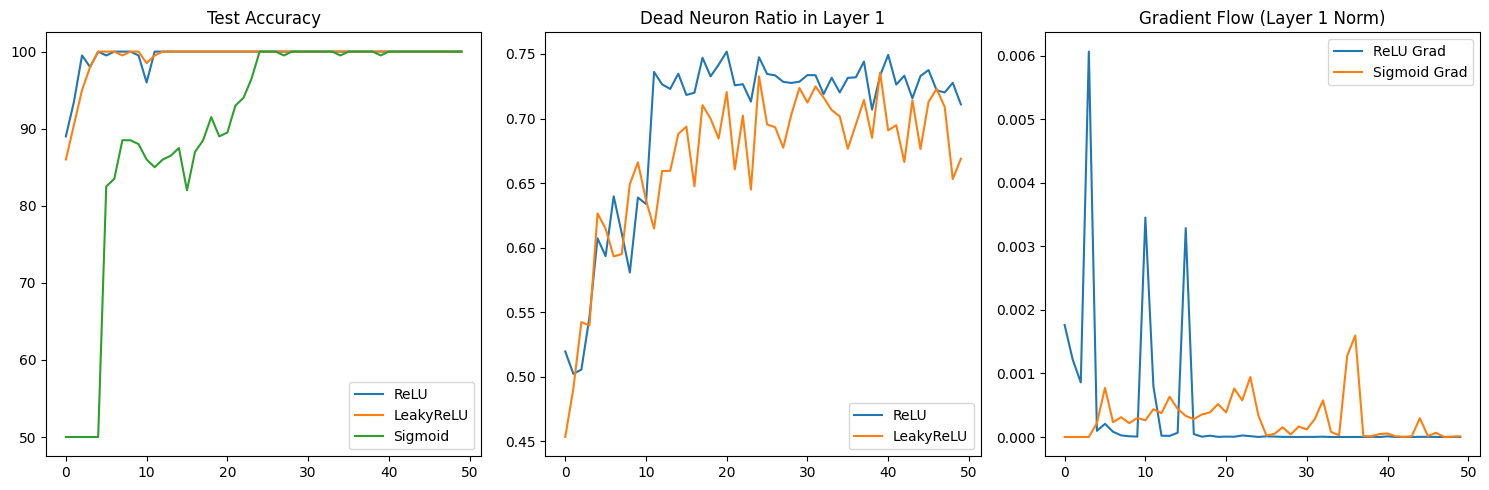

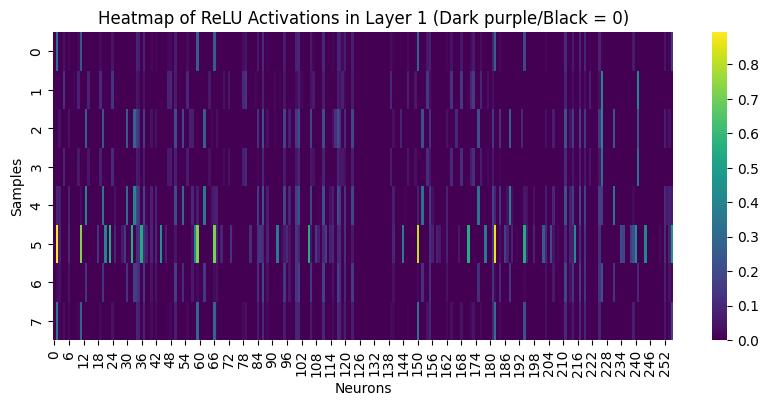

In [5]:
print("=== [실험 B] 활성화 함수 비교 ===")

# make_moons 데이터 로드
X, y = make_moons(n_samples=1000, noise=0.1, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

train_loader_moon = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=32, shuffle=True)
test_loader_moon = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)), batch_size=32, shuffle=False)

# 작은 가중치 초기값을 주어 Dead ReLU 유도
init_std_val = 0.01

model_relu = FlexibleMLP(2, 2, nn.ReLU(), init_std=init_std_val)
model_leaky = FlexibleMLP(2, 2, nn.LeakyReLU(0.01), init_std=init_std_val)
model_sig = FlexibleMLP(2, 2, nn.Sigmoid(), init_std=init_std_val)

opt_relu = optim.Adam(model_relu.parameters(), lr=0.01)
opt_leaky = optim.Adam(model_leaky.parameters(), lr=0.01)
opt_sig = optim.Adam(model_sig.parameters(), lr=0.01)

loss_fn = nn.CrossEntropyLoss()

# 학습 실행
print("\n[ReLU 학습]")
hist_relu = train_and_evaluate(model_relu, train_loader_moon, test_loader_moon, loss_fn, opt_relu, epochs=50)
print("\n[LeakyReLU 학습]")
hist_leaky = train_and_evaluate(model_leaky, train_loader_moon, test_loader_moon, loss_fn, opt_leaky, epochs=50)
print("\n[Sigmoid 학습]")
hist_sig = train_and_evaluate(model_sig, train_loader_moon, test_loader_moon, loss_fn, opt_sig, epochs=50)

# 시각화: Accuracy, Dead ReLU 비율, Gradient 크기 비교
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(hist_relu['test_acc'], label='ReLU')
plt.plot(hist_leaky['test_acc'], label='LeakyReLU')
plt.plot(hist_sig['test_acc'], label='Sigmoid')
plt.title('Test Accuracy')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(hist_relu['dead_relu_ratio'], label='ReLU')
plt.plot(hist_leaky['dead_relu_ratio'], label='LeakyReLU')
plt.title('Dead Neuron Ratio in Layer 1')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(hist_relu['grad_norm_l1'], label='ReLU Grad')
plt.plot(hist_sig['grad_norm_l1'], label='Sigmoid Grad')
plt.title('Gradient Flow (Layer 1 Norm)')
plt.legend()
plt.tight_layout()
plt.show()

# Layer 1의 Activation Heatmap (Dead ReLU 시각화)
plt.figure(figsize=(10, 4))
sns.heatmap(model_relu.activations['layer1'][:20], cmap='viridis')
plt.title('Heatmap of ReLU Activations in Layer 1 (Dark purple/Black = 0)')
plt.xlabel('Neurons')
plt.ylabel('Samples')
plt.show()

=== [실험 C] 최적화 알고리즘 비교 ===

[SGD 학습]
Epoch [1/20] Loss: 0.5454, Test Acc: 82.93%
Epoch [10/20] Loss: 0.2359, Test Acc: 85.94%
Epoch [20/20] Loss: 0.1534, Test Acc: 85.09%

[SGD + Momentum 학습]
Epoch [1/20] Loss: 0.5497, Test Acc: 83.53%
Epoch [10/20] Loss: 0.2793, Test Acc: 86.33%
Epoch [20/20] Loss: 0.2213, Test Acc: 87.22%

[Adam + Decay 학습]
Epoch [1/20] Loss: 0.4862, Test Acc: 85.03%
Epoch [10/20] Loss: 0.1817, Test Acc: 88.48%
Epoch [20/20] Loss: 0.0839, Test Acc: 89.63%


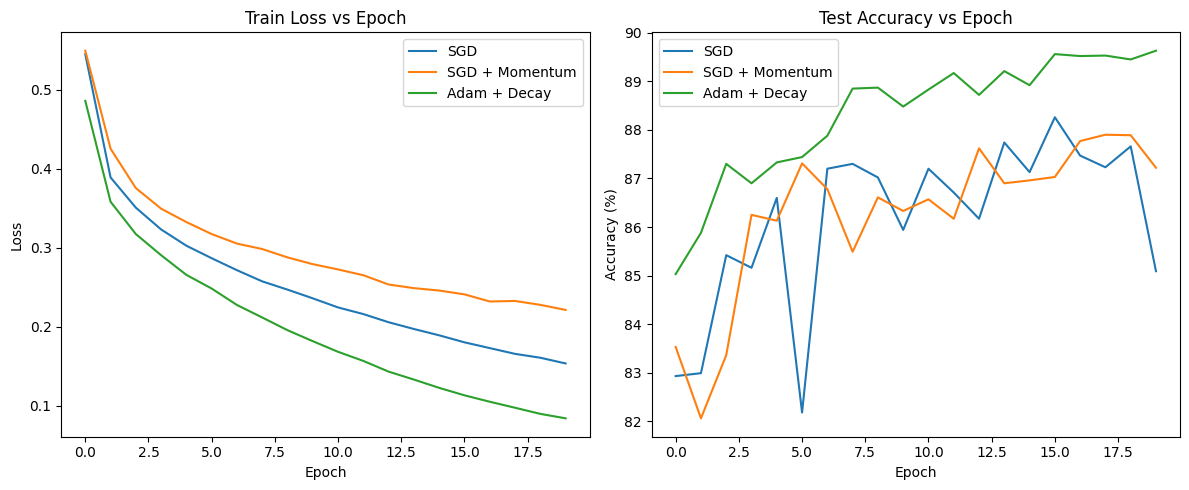

In [6]:
print("=== [실험 C] 최적화 알고리즘 비교 ===")

# 모델 세팅
model_sgd = FlexibleMLP(784, 10, nn.ReLU())
model_mom = FlexibleMLP(784, 10, nn.ReLU())
model_adam = FlexibleMLP(784, 10, nn.ReLU())

loss_fn = nn.CrossEntropyLoss()

# 옵티마이저 세팅
opt_sgd = optim.SGD(model_sgd.parameters(), lr=0.05)
opt_mom = optim.SGD(model_mom.parameters(), lr=0.05, momentum=0.9)
opt_adam = optim.Adam(model_adam.parameters(), lr=0.001)

# Adam Optimizer에 지수 감소(Exponential Decay) 스케줄러 적용
scheduler_adam = optim.lr_scheduler.ExponentialLR(opt_adam, gamma=0.9)

# 학습 실행
print("\n[SGD 학습]")
hist_sgd = train_and_evaluate(model_sgd, train_loader_fm, test_loader_fm, loss_fn, opt_sgd, epochs=20)
print("\n[SGD + Momentum 학습]")
hist_mom = train_and_evaluate(model_mom, train_loader_fm, test_loader_fm, loss_fn, opt_mom, epochs=20)
print("\n[Adam + Decay 학습]")
hist_adam = train_and_evaluate(model_adam, train_loader_fm, test_loader_fm, loss_fn, opt_adam, epochs=20, scheduler=scheduler_adam)

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_sgd['train_loss'], label='SGD')
plt.plot(hist_mom['train_loss'], label='SGD + Momentum')
plt.plot(hist_adam['train_loss'], label='Adam + Decay')
plt.title('Train Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_sgd['test_acc'], label='SGD')
plt.plot(hist_mom['test_acc'], label='SGD + Momentum')
plt.plot(hist_adam['test_acc'], label='Adam + Decay')
plt.title('Test Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.show()